# Post-Quantization Stats: SmoothQuant vs Baseline

Loads two JSON files produced by `collect_post_quant_stats()` and `collect_baseline_quant_stats()`
and compares them side-by-side.

Both files share the same schema and use `would_smooth` to tag layers, so every
layer can be aligned by name regardless of which run produced it.

**Activation fields (both files):**
- `act_pre_quant_max/mean`  — before fake-quantize (post-scaling in SQ run, raw in baseline)
- `act_post_quant_max/mean` — after fake-quantize (what the conv actually sees)

**Weight fields (both files):**
- `weight_actual_max/mean`  — per output-channel magnitude after calibration

In [10]:
import json, glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ── Load files ────────────────────────────────────────────────────────────────
sq_files       = sorted(glob.glob('post_quant_stats_adaround_r18_3_3_SQ05_42.json'))
baseline_files = sorted(glob.glob('baseline_quant_stats_adaround_r18_3_3_NOSQ_42.json'))

if not sq_files:
    raise FileNotFoundError('No post_quant_stats_*.json found')
if not baseline_files:
    print('⚠️  No baseline_quant_stats_*.json found — comparison plots will be skipped')
    has_baseline = False
else:
    has_baseline = True

sq_path = sq_files[-1]
print(f'SmoothQuant file:  {sq_path}')
with open(sq_path) as f:
    sq_raw = json.load(f)
sq_acc  = sq_raw.get('_accuracy', {})
sq_data = {k: v for k, v in sq_raw.items() if k != '_accuracy'}

if has_baseline:
    bl_path = baseline_files[-1]
    print(f'Baseline file:     {bl_path}')
    with open(bl_path) as f:
        bl_raw = json.load(f)
    bl_acc  = bl_raw.get('_accuracy', {})
    bl_data = {k: v for k, v in bl_raw.items() if k != '_accuracy'}
else:
    bl_data = {}
    bl_acc  = {}

print(f'\nSQ    layers: {len(sq_data)}   Baseline layers: {len(bl_data)}')

if sq_acc:
    print(f"SQ    Acc@1: {sq_acc.get('top1', 'N/A'):.3f}%   Acc@5: {sq_acc.get('top5', 'N/A'):.3f}%")
if bl_acc:
    print(f"Base  Acc@1: {bl_acc.get('top1', 'N/A'):.3f}%   Acc@5: {bl_acc.get('top5', 'N/A'):.3f}%")

SmoothQuant file:  post_quant_stats_adaround_r18_3_3_SQ05_42.json
Baseline file:     baseline_quant_stats_adaround_r18_3_3_NOSQ_42.json

SQ    layers: 20   Baseline layers: 20
SQ    Acc@1: 63.834%   Acc@5: 85.642%
Base  Acc@1: 63.678%   Acc@5: 85.544%


In [11]:
# ── Helpers ───────────────────────────────────────────────────────────────────
def safe_mean(v):
    return float(np.mean(v)) if v is not None else float('nan')

def max_over_median(v):
    """max / median — variance proxy. 1.0 = uniform. Large = outlier channels."""
    a = np.array(v)
    med = np.median(a)
    return float(a.max() / med) if med > 1e-8 else float('nan')

# Sorted layer order: would_smooth first, then not, then alphabetical within each group
sorted_layers = sorted(sq_data.keys(), key=lambda k: (not sq_data[k]['would_smooth'], k))

# Colour scheme
# SQ run: blue family   Baseline: green family   Weights: orange
C = {
    'sq_pre_ws':    '#2166ac',   # SQ pre-quant, would-smooth
    'sq_pre_nws':   '#92c5de',   # SQ pre-quant, NOT would-smooth
    'sq_post_ws':   '#c0392b',   # SQ post-quant, would-smooth
    'sq_post_nws':  '#f1948a',   # SQ post-quant, NOT would-smooth
    'bl_pre_ws':    '#1a7a4a',   # Baseline pre-quant, would-smooth
    'bl_pre_nws':   '#84c9a0',   # Baseline pre-quant, NOT would-smooth
    'bl_post_ws':   '#7d3c98',   # Baseline post-quant, would-smooth
    'bl_post_nws':  '#c39bd3',   # Baseline post-quant, NOT would-smooth
    'w_ws':         '#e07b00',   # Weight, would-smooth
    'w_nws':        '#f5c97a',   # Weight, NOT would-smooth
}

def sq_col(name, post=False):
    ws = sq_data[name]['would_smooth']
    if post: return C['sq_post_ws']  if ws else C['sq_post_nws']
    return          C['sq_pre_ws']   if ws else C['sq_pre_nws']

def bl_col(name, post=False):
    ws = sq_data[name]['would_smooth']  # use SQ tag as ground truth for alignment
    if post: return C['bl_post_ws']  if ws else C['bl_post_nws']
    return          C['bl_pre_ws']   if ws else C['bl_pre_nws']

def w_col(name):
    return C['w_ws'] if sq_data[name]['would_smooth'] else C['w_nws']

print(f'Sorted layers: {len(sorted_layers)}')
print(f"Would-smooth:      {sum(1 for n in sorted_layers if sq_data[n]['would_smooth'])}")
print(f"Would-NOT-smooth:  {sum(1 for n in sorted_layers if not sq_data[n]['would_smooth'])}")

Sorted layers: 20
Would-smooth:      8
Would-NOT-smooth:  12


## 1 — Activation Max Spread Boxplot: SQ vs Baseline
4 boxes per layer: SQ pre/post-quant (blue/red) + Baseline pre/post-quant (green/purple).
SmoothQuant should make the blue boxes tighter than the green ones for would-smooth layers.

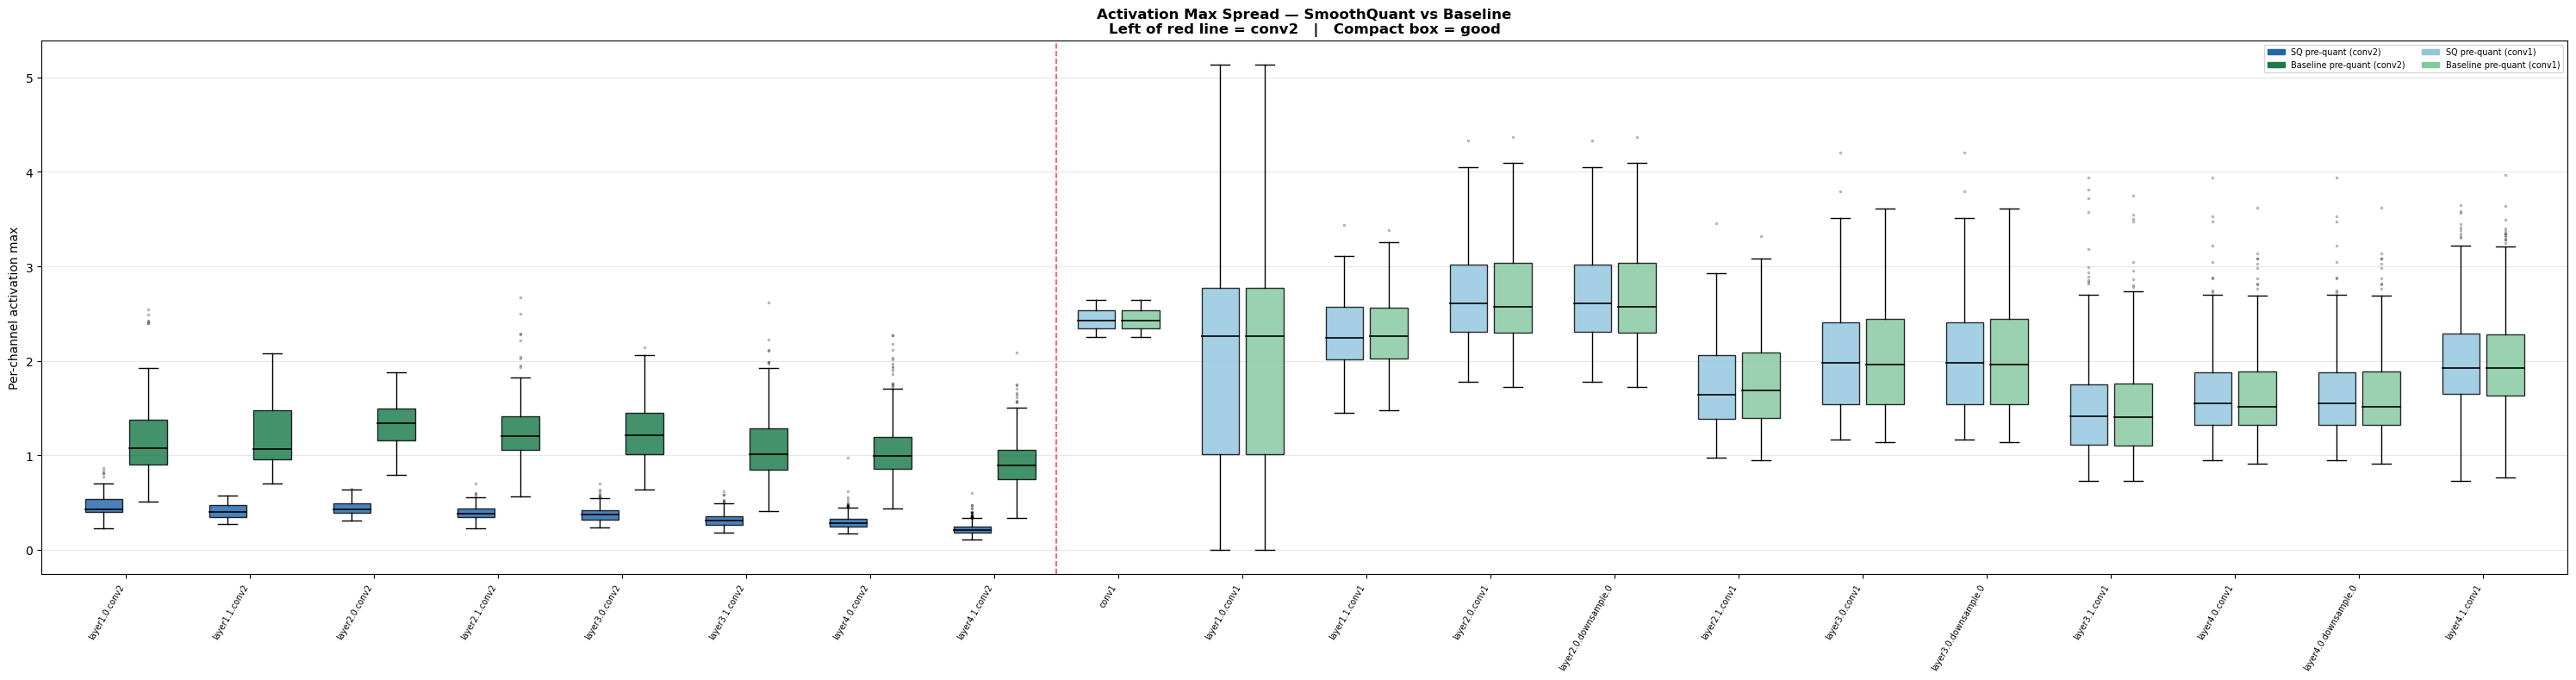

In [22]:
act_layers = [n for n in sorted_layers if sq_data[n]['act_pre_quant_max'] is not None]
n = len(act_layers)
n_ws = sum(1 for n_ in act_layers if sq_data[n_]['would_smooth'])

# 2 offsets per layer (pre only)
offsets   = [-0.18, 0.18]
width     = 0.30
positions = {key: np.arange(1, n + 1) + off for key, off in zip(['sq_pre','bl_pre'], offsets)}

def get_arr(data_dict, name, field):
    v = data_dict.get(name, {}).get(field)
    return np.array(v) if v is not None else np.array([float('nan')])

fig, ax = plt.subplots(figsize=(max(18, n * 1.5), 8))

for key, col_fn, data_dict, field in [
    ('sq_pre', lambda i: sq_col(act_layers[i]), sq_data, 'act_pre_quant_max'),
    ('bl_pre', lambda i: bl_col(act_layers[i]), bl_data, 'act_pre_quant_max'),
]:
    if not has_baseline and 'bl' in key:
        continue

    arrays = [get_arr(data_dict, name, field) for name in act_layers]

    bp = ax.boxplot(
        arrays,
        positions=positions[key],
        widths=width,
        patch_artist=True,
        showfliers=True,
        flierprops=dict(marker='o', markersize=1.5, alpha=0.3),
        medianprops=dict(color='black', linewidth=1.2)
    )

    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(col_fn(i))
        patch.set_alpha(0.82)

ax.set_xticks(np.arange(1, n + 1))
ax.set_xticklabels(act_layers, rotation=60, ha='right', fontsize=7)

ax.axvline(x=n_ws + 0.5, color='red', linestyle='--', linewidth=1.2, alpha=0.7)

ax.set_ylabel('Per-channel activation max')
ax.set_title(
    'Activation Max Spread — SmoothQuant vs Baseline\n'
    'Left of red line = conv2   |   Compact box = good',
    fontweight='bold'
)

ax.grid(axis='y', alpha=0.3)

ax.legend(handles=[
    Patch(color=C['sq_pre_ws'],  label='SQ pre-quant (conv2)'),
    Patch(color=C['bl_pre_ws'],  label='Baseline pre-quant (conv2)'),
    Patch(color=C['sq_pre_nws'], label='SQ pre-quant (conv1)'),
    Patch(color=C['bl_pre_nws'], label='Baseline pre-quant (conv1)'),
], ncol=2, fontsize=7)

plt.tight_layout()
plt.savefig('boxplot_pre_quant_sq_vs_baseline.png', dpi=120, bbox_inches='tight')
plt.show()